# Selfish vs Altruistic Agents

## Altruistic Agents

In [1]:
from environment import TrafficEnvironment
from keychain import Keychain as kc
import os
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3 import PPO
import supersuit as ss
from Sumo_controller import Sumo

from utilities import confirm_env_variable
from utilities import get_params
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [2]:
confirm_env_variable(kc.SUMO_HOME, append="tools")
params = get_params(kc.PARAMS_PATH)

[CONFIRMED] Environment variable exists: SUMO_HOME
[SUCCESS] Added module directory: C:\Program Files (x86)\Eclipse\Sumo\tools


In [3]:
Sumo_sim=Sumo(params)
Sumo_sim.Sumo_start()

In [4]:
env = TrafficEnvironment(params[kc.ENVIRONMENT_PARAMETERS], params[kc.SIMULATION_PARAMETERS], params[kc.AGENTS_GENERATION_PARAMETERS])

[SUCCESS] Generated & saved 12 paths to: paths.csv
[SUCCESS] Environment initiated!
[INFO] Free-flow times:  {(0, 0): [118.99519329059385, 129.82305441522092, 47.68608634173604], (0, 1): [91.75980603904627, 2215.892869391318, 381.00678714882946], (1, 0): [14.980030269847319, 473.5989722438803, 45.19956318955831], (1, 1): [198.5956816919048, 1329.101561406335, 2145.53926411777]}
[SUCCESS] Free flow times calculated!


In [5]:
env = ss.pettingzoo_env_to_vec_env_v1(env)
env = ss.concat_vec_envs_v1(env, 1, num_cpus=2, base_class="stable_baselines3")

In [12]:
env.reward_table = []
env.actions = []
env.actions2 = []        

In [7]:
tuned_params = {
        "gamma": 0.9,
        "learning_rate": 1e-3,
    }

model = PPO(
    "MlpPolicy",
    env,
    verbose = 1,
    n_steps = 10,
    batch_size=10,
    **tuned_params
)

Using cpu device


In [13]:
model.learn(total_timesteps=400)##try more timesteps

----------------------------
| time/              |     |
|    fps             | 0   |
|    iterations      | 1   |
|    time_elapsed    | 173 |
|    total_timesteps | 20  |
----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 0            |
|    iterations           | 2            |
|    time_elapsed         | 303          |
|    total_timesteps      | 40           |
| train/                  |              |
|    approx_kl            | 0.0015467256 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.07        |
|    explained_variance   | 0.000569     |
|    learning_rate        | 0.001        |
|    loss                 | 7.32e+05     |
|    n_updates            | 40           |
|    policy_gradient_loss | -0.0151      |
|    value_loss           | 9.42e+05     |
------------------------------------------
-----------------------

Reward table is:  [-956.8166666666667, -956.8166666666667, -1579.175, -214.7, -214.7, -223.89999999999998, -1579.175, -214.7, -1008.825, -214.7, -1526.6499999999999, -1000.4583333333333, -1526.6499999999999, -956.8166666666667, -214.7, -1008.825, -214.7, -956.8166666666667, -956.8166666666667, -1526.6499999999999, -214.7, -1570.0, -1000.4583333333333, -171.24166666666665, -214.7, -223.89999999999998, -171.24166666666665, -956.8166666666667, -1008.825, -223.89999999999998, -1000.4583333333333, -214.7, -223.89999999999998, -1000.4583333333333, -1579.175, -214.7, -171.24166666666665, -1579.175, -1526.6499999999999, -171.24166666666665, -214.7, -1000.4583333333333, -214.7, -956.8166666666667, -214.7, -214.7, -1570.0, -214.7, -214.7, -1008.825, -1570.0, -171.24166666666665, -223.89999999999998, -1570.0, -223.89999999999998, -956.8166666666667, -1000.4583333333333, -214.7, -214.7, -1000.4583333333333, -1570.0, -1000.4583333333333, -956.8166666666667, -956.8166666666667, -171.24166666666665, 

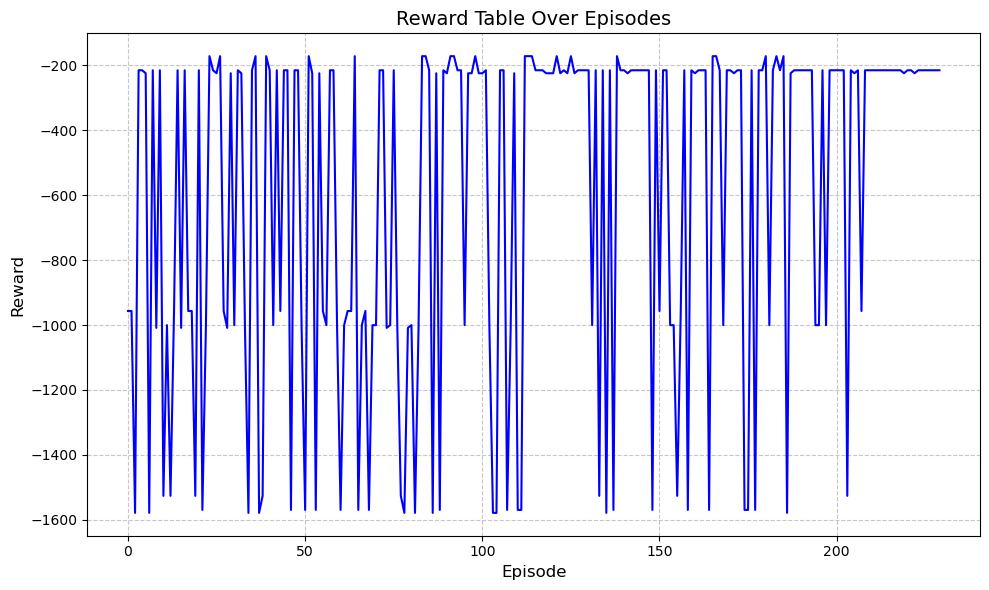

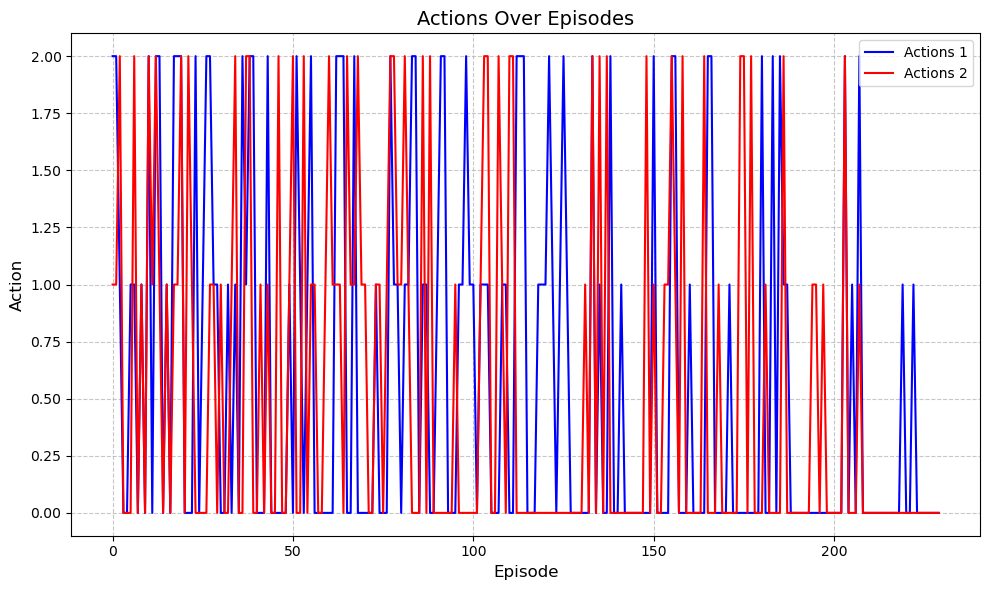

In [14]:
env.close()

## Selfish Agents